## 08-06-2026 PLOTLY AND CUFFLINKS
Matplotlib gives static images. Plotly gives interactive charts I can hover, zoom and pan.

Cufflinks is the glue that lets me call `.iplot()` straight off a pandas DataFrame instead of writing plotly by hand. The charts below show a static preview here, they are fully interactive when I run the notebook myself.

In [1]:
# install (plotly and cufflinks come from pip, not conda)
# !pip install plotly cufflinks
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import cufflinks as cf
from plotly.offline import iplot, init_notebook_mode
init_notebook_mode(connected=True)
cf.go_offline()           # run plotly locally, no account needed
np.random.seed(7)

In [2]:
# sample data - three random walks shifted up so values stay positive
df = pd.DataFrame(np.random.randn(100, 3), columns=['A', 'B', 'C'])
for c in ['A', 'B', 'C']:
    df[c] = df[c].cumsum() + 20
df.head()

,A,B,C
0,21.690526,19.534063,20.032820
1,22.098042,18.745140,20.034886
2,22.097152,16.990415,21.052544
3,22.697650,16.364986,20.880995
4,23.202949,16.103630,20.638246


### Line Plot

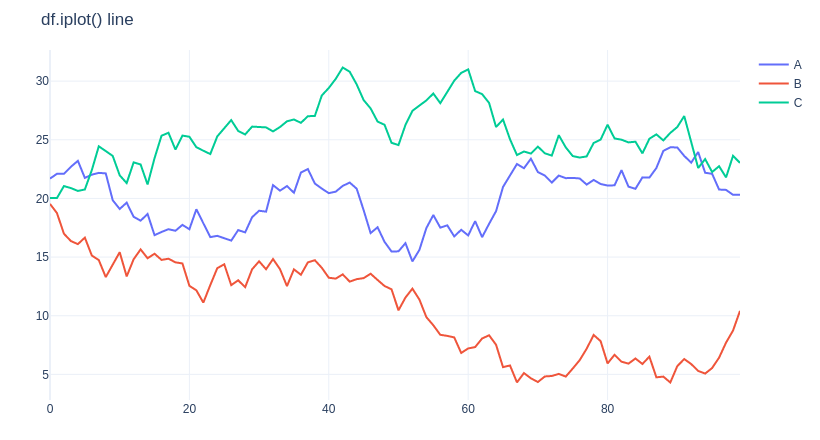

In [ ]:
# iplot() - interactive twin of plot(). Hover to read values, zoom, toggle lines
df.iplot()

### Scatter and Bubble

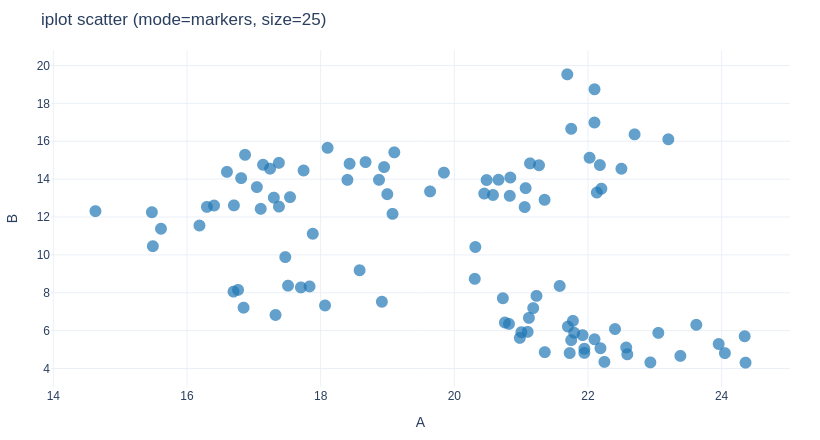

In [ ]:
# mode='markers' draws points, size sets the marker size (bubble style)
df.iplot(x='A', y='B', mode='markers', size=25)

### Bar Charts

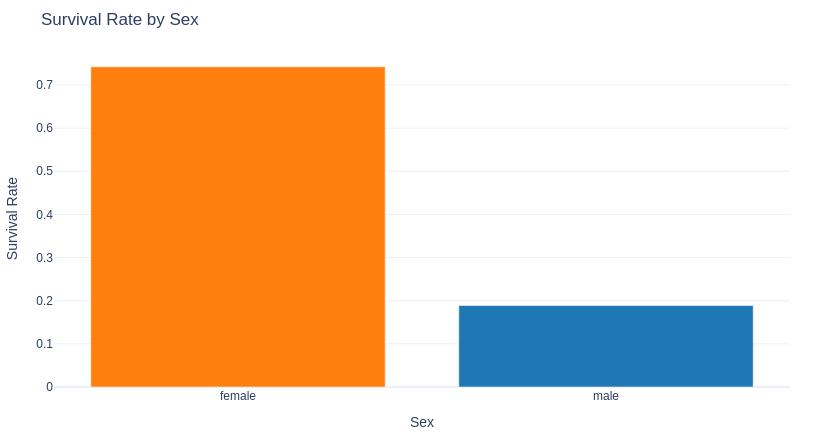

In [ ]:
# load titanic, average survival by sex, plot as bars
titanic = sns.load_dataset('titanic')
surv = titanic.groupby('sex')['survived'].mean().reset_index()
surv.iplot(kind='bar', x='sex', y='survived', title='Survival Rate by Sex')

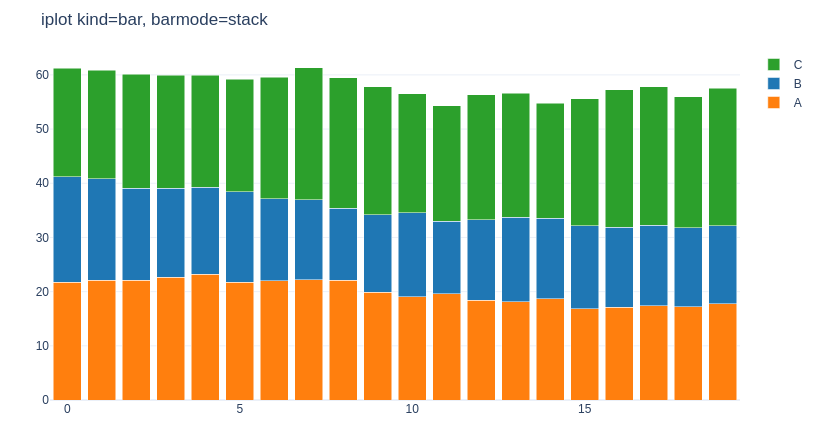

In [ ]:
# barmode='stack' stacks the columns into one bar, bargap adds spacing
df.iplot(kind='bar', barmode='stack', bargap=0.5)

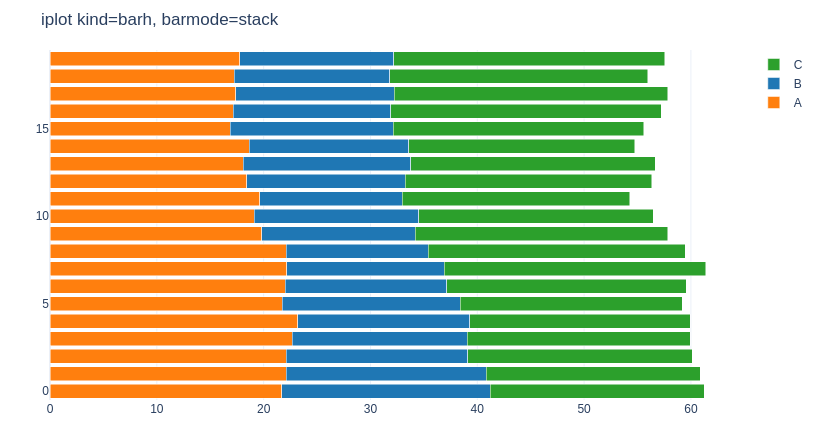

In [ ]:
# barh - horizontal stacked bars
df.iplot(kind='barh', barmode='stack', bargap=0.5)

### Box Plot

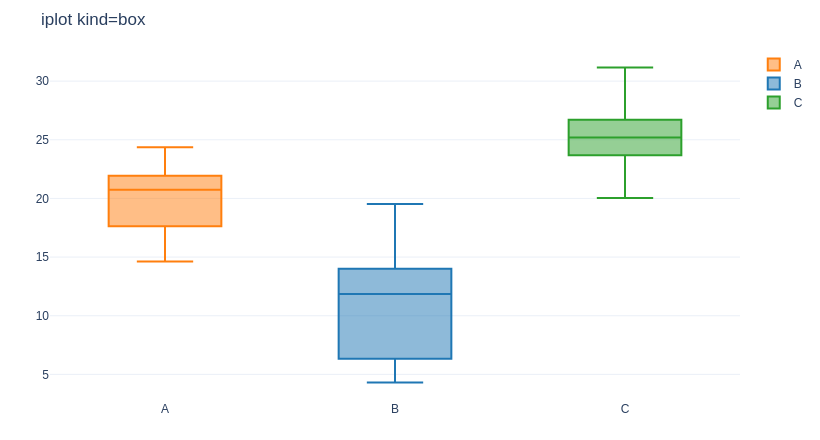

In [ ]:
# box - shows min, q1, median, q3, max per column on hover
df.iplot(kind='box')

### Area Plot

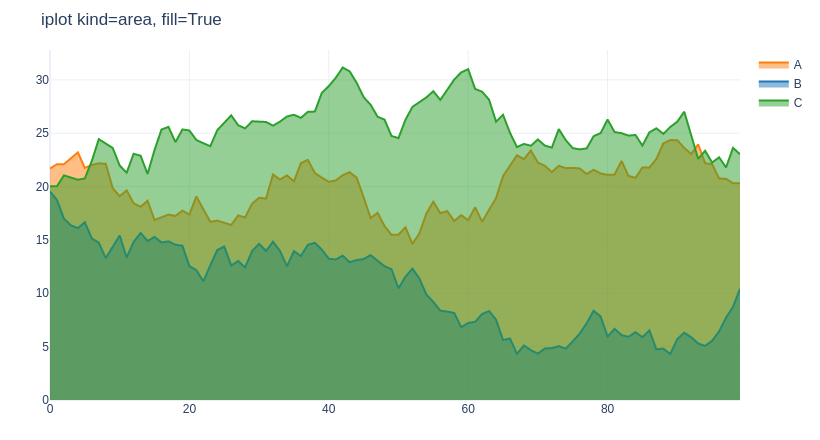

In [ ]:
# area - fills the space under each line
df.iplot(kind='area', fill=True)

### 3D Plots

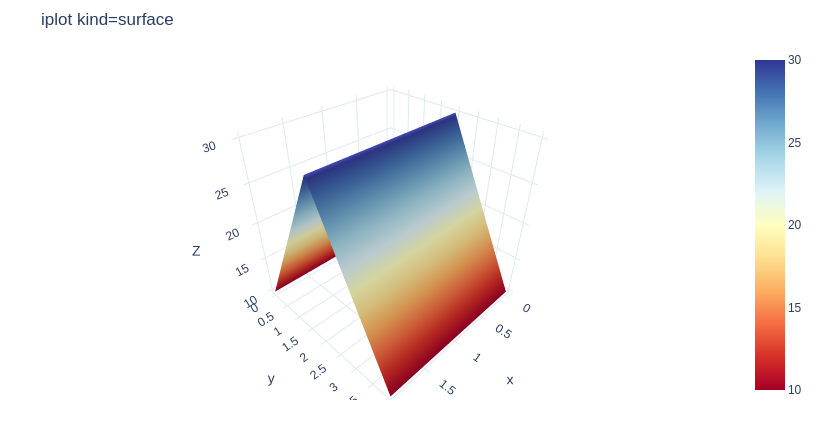

In [ ]:
# surface - needs a grid of z values, colorscale sets the colours
df3 = pd.DataFrame({'X': [10, 20, 30, 20, 10], 'Y': [10, 20, 30, 20, 10], 'Z': [10, 20, 30, 20, 10]})
df3.iplot(kind='surface', colorscale='rdylbu')

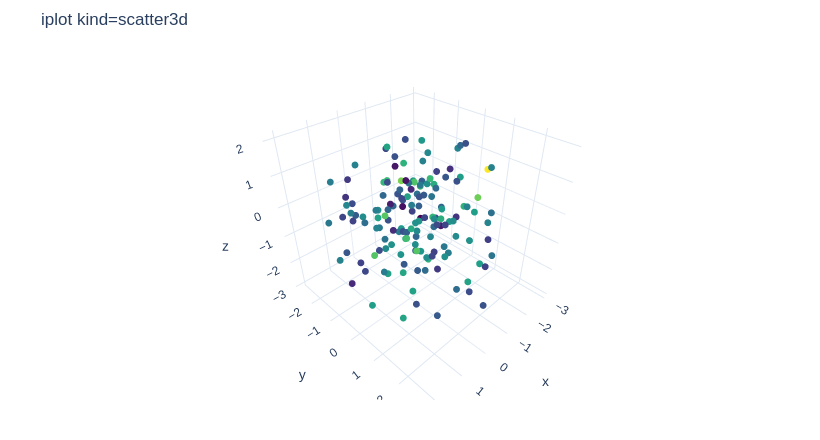

In [ ]:
# scatter3d - 3D point cloud. cf.datagen makes demo data in the right shape
cf.datagen.scatter3d(2, 150, mode='stocks').iplot(kind='scatter3d', x='x', y='y', z='z')

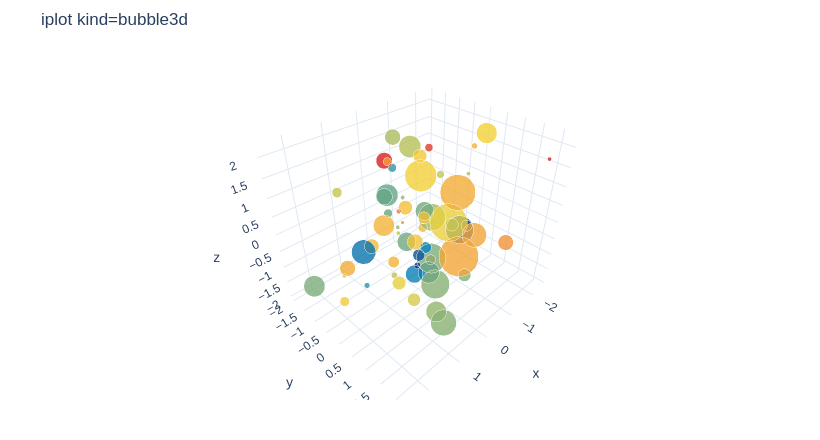

In [ ]:
# bubble3d - 3D points sized by a value
cf.datagen.bubble3d(5, 4, mode='stocks').iplot(kind='bubble3d', x='x', y='y', z='z', size='size')

### Spread, Histogram, Heatmap

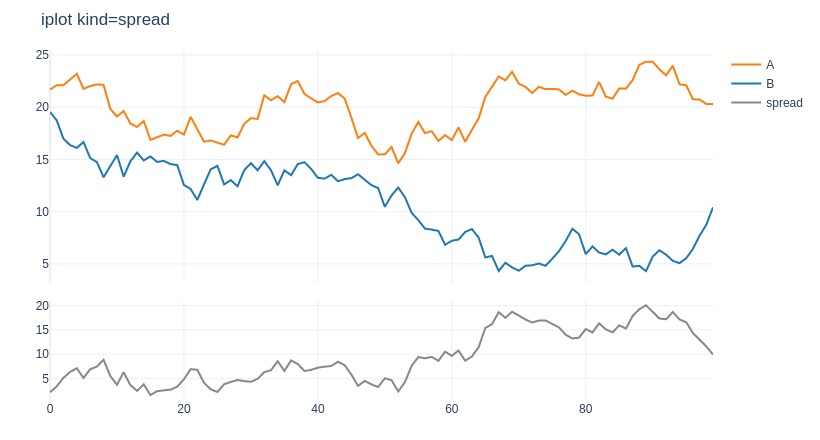

In [ ]:
# spread - plots two series plus the gap between them below
df[['A', 'B']].iplot(kind='spread')

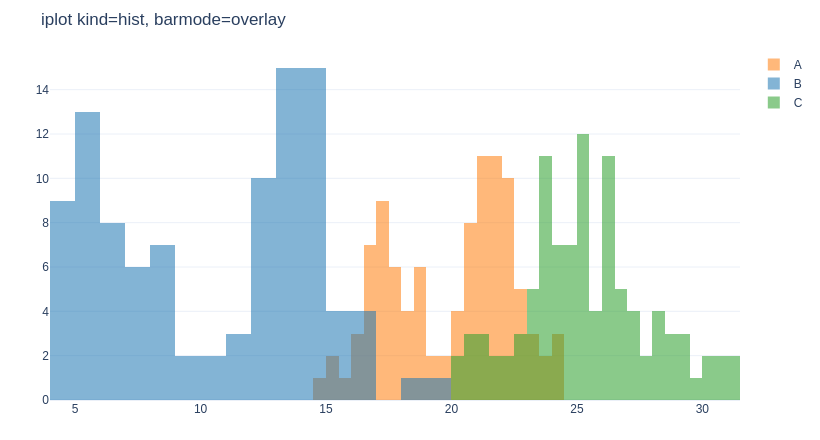

In [ ]:
# hist with barmode='overlay' overlaps the distributions
df.iplot(kind='hist', bins=25, barmode='overlay', bargap=0.5)

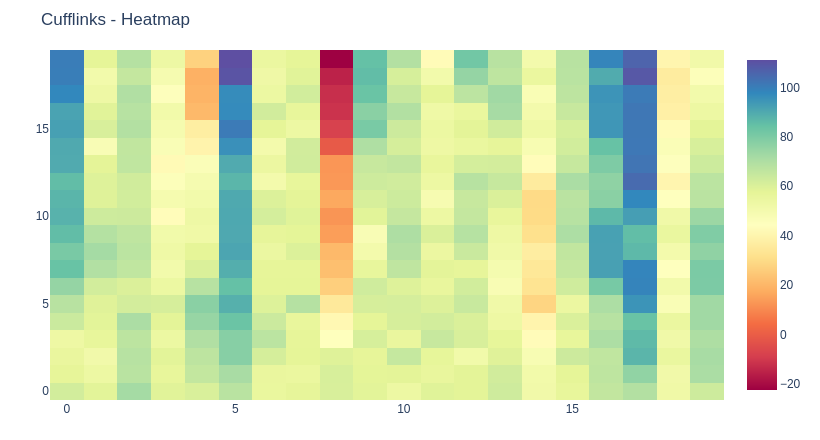

In [ ]:
# heatmap - colours a grid by value
cf.datagen.heatmap(20, 20).iplot(kind='heatmap', colorscale='spectral', title='Cufflinks - Heatmap')